In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.3 MB/s eta 0:00:00


In [7]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [3]:
wiki = api.load('glove-wiki-gigaword-50')
twit = api.load('glove-twitter-50')

[==================================================] 100.0% 66.0/66.0MB downloaded
[==================================================] 100.0% 199.5/199.5MB downloaded


In [6]:
print(f'Wikipedia model has {wiki.vectors.shape[0]:,} words and {wiki.vectors.shape[1]:} embedding dimensions')
print(f'Twitter model has {twit.vectors.shape[0]:,} words and {twit.vectors.shape[1]:} embedding dimensions')

Wikipedia model has 400,000 words and 50 embedding dimensions
Twitter model has 1,193,514 words and 50 embedding dimensions


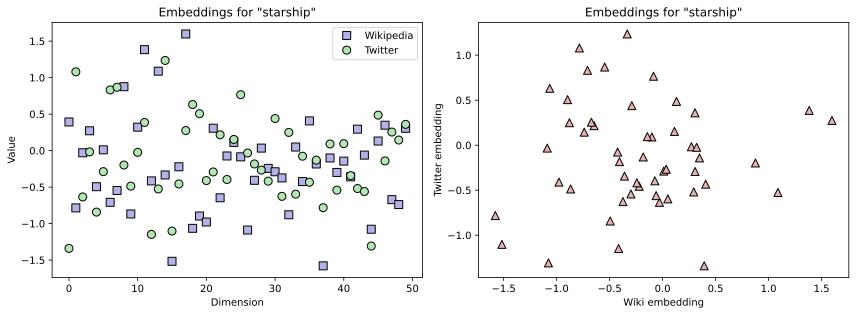

In [8]:
targetword = 'starship'

_,axs = plt.subplots(1,2,figsize=(12,4.5))
axs[0].plot(wiki[targetword],'ks',markerfacecolor=[.7,.7,.9],markersize=8,label='Wikipedia')
axs[0].plot(twit[targetword],'ko',markerfacecolor=[.7,.9,.7],markersize=8,label='Twitter')
axs[0].set(xlabel='Dimension',ylabel='Value',title=f'Embeddings for "{targetword}"')
axs[0].legend()

axs[1].plot(wiki[targetword],twit[targetword],'k^',markerfacecolor=[.9,.7,.7],markersize=8)
axs[1].set(xlabel='Wiki embedding',ylabel='Twitter embedding',title=f'Embeddings for "{targetword}"')

plt.tight_layout()
plt.show()

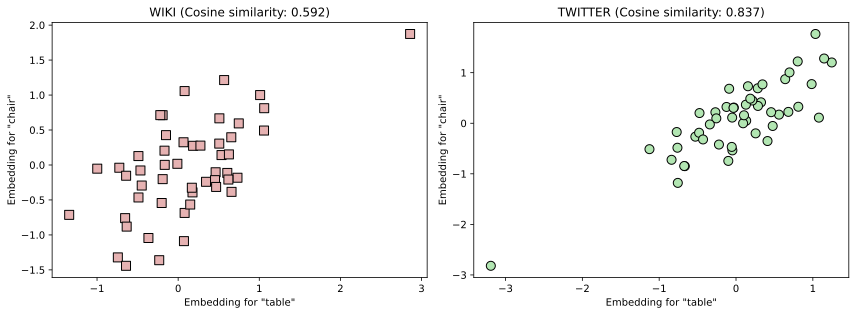

In [9]:
word1 = 'table'
word2 = 'chair'

# scatter plot for wiki
_,axs = plt.subplots(1,2,figsize=(12,4.5))
axs[0].plot(wiki[word1],wiki[word2],'ks',markersize=9,markerfacecolor=[.9,.7,.7])
axs[0].set(xlabel=f'Embedding for "{word1}"',ylabel=f'Embedding for "{word2}"',
           title=f'WIKI (Cosine similarity: {wiki.similarity(word1,word2):.3f})')


# scatter plot for twitter
axs[1].plot(twit[word1],twit[word2],'ko',markersize=9,markerfacecolor=[.7,.9,.7])
axs[1].set(xlabel=f'Embedding for "{word1}"',ylabel=f'Embedding for "{word2}"',
           title=f'TWITTER (Cosine similarity: {twit.similarity(word1,word2):.3f})')

plt.tight_layout()
plt.show()

In [14]:
print('10 words most similar to "battery" in wiki:')
for w,cs in wiki.most_similar('battery'):
  print(f' {w:>15} with similarity {cs:.4f}')

print('\nAnd in twitter:')
for w,cs in twit.most_similar('battery'):
  print(f' {w:>15} with similarity {cs:.4f}')

10 words most similar to "battery" in wiki:
       batteries with similarity 0.8322
    rechargeable with similarity 0.7258
     lithium-ion with similarity 0.7083
          weapon with similarity 0.6928
         machine with similarity 0.6788
       lead-acid with similarity 0.6765
          device with similarity 0.6706
   anti-aircraft with similarity 0.6586
             gun with similarity 0.6580
        electric with similarity 0.6577

And in twitter:
         charger with similarity 0.8721
            cell with similarity 0.8216
       batteries with similarity 0.8167
          laptop with similarity 0.8139
            batt with similarity 0.8043
        charging with similarity 0.7881
     replacement with similarity 0.7854
         adapter with similarity 0.7587
           phone with similarity 0.7572
          charge with similarity 0.7499


# Exercise 5: foxes and dogs

In [22]:
text = 'The quick brown fox jumps over the lazy dog'

import re
words = re.split('\\s',text.lower())

# index sequence in the two embeddings
wiki_idx = [wiki.key_to_index[w] if w in wiki.key_to_index else np.inf for w in words ]
twit_idx = [twit.key_to_index[w] if w in twit.key_to_index else np.inf for w in words ]

print(' Word |  Wiki | Twitter')
print('-'*23)
for o,w,t in zip(words,wiki_idx,twit_idx):
  print(f'{o:>5} | {w:>5} | {t:>5}')

 Word |  Wiki | Twitter
-----------------------
  the |     0 |    13
quick |  2582 |  2156
brown |  1042 |  1871
  fox |  2106 |  4000
jumps | 11070 | 18014
 over |    74 |   254
  the |     0 |    13
 lazy | 16531 |  2222
  dog |  2926 |  1317


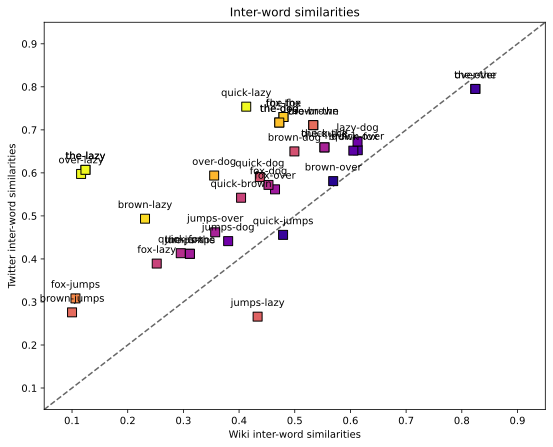

In [23]:
# get all unique inter-word similarities

plt.figure(figsize=(9,7))

# start range at 0 or 1?
for i in range(0,len(words)):
  for j in range(i+1,len(words)):

    # skip identity
    if words[i]==words[j]: continue

    # calculate the cosine similarities for the two embeddings
    cs_wiki = wiki.similarity(wiki_idx[i],wiki_idx[j])
    cs_twit = twit.similarity(twit_idx[i],twit_idx[j])

    # calculate the distance to the unity line
    v = np.array([cs_wiki,cs_twit])
    u = np.array([1,1])
    dist = np.linalg.norm(v - (sum(v*u))/(np.linalg.norm(u)**2)*u)

    # draw the results at the coordinates
    plt.plot(cs_wiki,cs_twit,'ks',markersize=9,markerfacecolor=mpl.cm.plasma(dist*5))

    # and write the word pair
    plt.text(cs_wiki,cs_twit+.02,f'{words[i]}-{words[j]}',va='bottom',ha='center')



# plot the unity line
xylims = [.05,.95]
plt.plot(xylims,xylims,'--',color=[.4,.4,.4],zorder=-30)

# final adjustments
plt.gca().set(xlim=xylims,ylim=xylims,xlabel='Wiki inter-word similarities',
              ylabel='Twitter inter-word similarities',title='Inter-word similarities')
plt.show()